In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import constants

from centrex_trajectories import (
    Coordinates,
    Gravity,
    Velocities,
    propagate_trajectories,
    PropagationOptions,
)
from centrex_trajectories.random_generation import (
    generate_random_coordinates_uniform_circle,
)
from centrex_trajectories.particles import TlF, Particle
from centrex_trajectories.beamline_objects import (
    ElectrostaticQuadrupoleLens,
    Bore,
)
from centrex_tlf import states, hamiltonian
from centrex_trajectories.utils import fit_stark_potential
from eigenshuffle import eigenshuffle_eigh

from physics_augment import (
    fit_stark_even_keep_domain,
    augment_with_physics_extended_smooth,
)
from data_creation import build_raw_dataset_full, load_raw_data_full, save_raw_data_full
from classifier_code import (
    Standardizer,
    train_classifier,
    evaluate_classifier,
    calibrate_temperature,
)

from regressor_code import (
    TrainCfgReg5,
    train_regressor5_slopes,
    SurrogateXYV,
    evaluate_regressor5,
)
from visualize import compute_error_maps_full, show_error_plots_full

import torch

In [2]:
plt.rcParams.update({"font.size": 14})


In [3]:
rng = np.random.default_rng(seed=42)  # For reproducibility

In [4]:
device = "cpu"

In [5]:
# # generate states up to J=6
# QN = states.generate_uncoupled_states_ground(Js=np.arange(7))

# # generate the X hamiltonian terms
# H = hamiltonian.generate_uncoupled_hamiltonian_X(QN)

# # create a function outputting the hamiltonian as a function of E and B
# Hfunc = hamiltonian.generate_uncoupled_hamiltonian_X_function(H)

# # V/cm
# Ez = np.linspace(0, 50e3, 2_001)

# # generate the Hamiltonian for (almost) zero field, add a small field to make states
# # non-degenerate
# Hi = Hfunc(E=[0, 0, 1e-3], B=[0, 0, 1e-3])
# E, V = np.linalg.eigh(Hi)

# # run eigenshuffle to track the states
# Ez = np.append(np.linspace(0, 1_000, 501), np.linspace(2_000, 50_000, 51))
# hamiltonians = np.array([Hfunc(E=[0, 0, Ei], B=[0, 0, 1e-3]) for Ei in Ez])
# es, vs = eigenshuffle_eigh(hamiltonians)

# # get the true superposition-states of the system
# QN_states = hamiltonian.matrix_to_states(vs[0], QN)


In [6]:
# indices_J2 = [idx for idx, s in enumerate(QN_states) if s.largest.J == 2]

# indices_J2_F3 = (
#     indices_J2[0]
#     + np.where(
#         [
#             qn.largest.F == 3
#             for qn in [
#                 qn.remove_small_components().transform_to_coupled()
#                 for qn in [QN_states[idx] for idx in indices_J2]
#             ]
#         ]
#     )[0]
# )
# indices_J2_other = [idx for idx in indices_J2 if idx not in indices_J2_F3]

# indices_J2_mF0 = (
#     indices_J2[0]
#     + np.where(
#         [
#             qn.largest.mF == 0 and qn.largest.F == 3
#             for qn in [
#                 qn.remove_small_components().transform_to_coupled()
#                 for qn in [QN_states[idx] for idx in indices_J2]
#             ]
#         ]
#     )[0]
# )

# indices_J2_mF2 = (
#     indices_J2[0]
#     + np.where(
#         [
#             qn.largest.mF == 2 and qn.largest.F == 3
#             for qn in [
#                 qn.remove_small_components().transform_to_coupled()
#                 for qn in [QN_states[idx] for idx in indices_J2]
#             ]
#         ]
#     )[0]
# )

# indices_J2_mF3 = (
#     indices_J2[0]
#     + np.where(
#         [
#             qn.largest.mF == 3
#             for qn in [
#                 qn.remove_small_components().transform_to_coupled()
#                 for qn in [QN_states[idx] for idx in indices_J2]
#             ]
#         ]
#     )[0]
# )


In [7]:
# # convert to V/m
# Ez_Vm = Ez * 100

# # grab energy of J=2, mF=0, 2 & 3
# # mF=-1,0,1 have more or less the same energy levels, just slight differences at higher
# # fields
# energy = es.real[:, indices_J2_mF0[0]] * constants.hbar
# fit_coeff_mF0 = fit_stark_potential(Ez_Vm, energy, deg=11)

# energy = es.real[:, indices_J2_mF2[0]] * constants.hbar
# fit_coeff_mF2 = fit_stark_potential(Ez_Vm, energy, deg=11)

# energy = es.real[:, indices_J2_mF3[0]] * constants.hbar
# fit_coeff_mF3 = fit_stark_potential(Ez_Vm, energy, deg=11)


In [8]:
def run_trajectory_simulation(
    R: float,
    V: float,
    L: float,
    n_trajectories: int,
    rng,
    options: PropagationOptions,
    particle: Particle,
    gravity: Gravity,
):
    origin = generate_random_coordinates_uniform_circle(
        radius=R, number=n_trajectories, x=0, y=0, z=-1e-2, rng=rng
    )
    velocities = Velocities(
        rng.uniform(-10, 10, n_trajectories),
        rng.uniform(-10, 10, n_trajectories),
        rng.uniform(100, 250, n_trajectories),
    )

    eql = ElectrostaticQuadrupoleLens(
        name="Electrostatic Lens",
        objects=[
            Bore(
                x=0,
                y=0,
                z=0,
                length=L,
                radius=R,
            )
        ],
        start=0,
        stop=L,
        V=V,
        R=R,
        save_collisions=True,
    )

    sections = [eql]
    section_data, trajectories = propagate_trajectories(
        sections,
        origin,
        velocities,
        particle,
        force=gravity,
        options=options,
    )
    dt = -origin.z / velocities.vz
    coords_init = Coordinates(
        x=origin.x + velocities.vx * dt,
        y=origin.y + velocities.vy * dt,
        z=np.zeros_like(origin.z),
    )
    velocities_init = velocities
    coords_final, velocities_final = (
        trajectories.get_coordinates_velocities_at_position(z=L)
    )
    indices_survive = np.array(list(trajectories.keys()))
    return coords_init, coords_final, velocities_init, velocities_final, indices_survive

In [9]:
# 1) Fit Stark, get alpha0 (you already have this step)
# P_t, alpha0 = fit_stark_even_keep_domain(Ez_Vm, energy, deg_even=12)
alpha0 = np.float64(3.42909943128328e-49)

# 2) Build training data across voltages
rng = np.random.default_rng(seed=42)
particle = TlF()
gravity = Gravity(0, -9.81 * particle.mass, 0)
options = PropagationOptions(verbose=False, n_cores=8)
L = 0.6
R = 1.75 * 25.4e-3 / 2

In [10]:
try:
    data_tr_full, meta_tr = load_raw_data_full("data_tr_full.npz")
    data_va_full, meta_va = load_raw_data_full("data_va_full.npz")
    data_te_full, meta_te = load_raw_data_full("data_te_full.npz")
except:
    V_list = np.linspace(0, 30_000, 11)
    # 1) Rebuild splits with velocities (you can keep your existing classifier)
    #    If you already have data_tr/va/te for classifier, you can just build here for regressor:

    per_V_train, per_V_val, per_V_test = 100_000, 40_000, 100_000

    meta_train = {
        "V_list": list(V_list),  # list of lens voltages
        "R": R,  # lens bore radius [m]
        "L": L,  # lens length [m]
        "per_V": {  # number of trajectories per voltage
            "train": per_V_train,
            "val": per_V_val,
            "test": per_V_test,
        },
        "split": "train",  # dataset split
        "mass": particle.mass,  # optional: molecule or atom
        "gravity": (gravity.fx, gravity.fy, gravity.fz),  # if used in simulation
    }

    data_tr_full = build_raw_dataset_full(
        V_list,
        per_V_train,
        R,
        L,
        rng,
        options,
        particle,
        gravity,
        run_trajectory_simulation,
    )
    data_va_full = build_raw_dataset_full(
        V_list,
        per_V_val,
        R,
        L,
        rng,
        options,
        particle,
        gravity,
        run_trajectory_simulation,
    )
    data_te_full = build_raw_dataset_full(
        V_list,
        per_V_test,
        R,
        L,
        rng,
        options,
        particle,
        gravity,
        run_trajectory_simulation,
    )

    save_raw_data_full(
        data_tr_full,
        "data_tr_full.npz",
        meta=meta_train,
    )

    meta_val = meta_train | {"split": "val"}
    meta_test = meta_train | {"split": "test"}

    save_raw_data_full(data_va_full, "data_va_full.npz", meta=meta_val)
    save_raw_data_full(data_te_full, "data_te_full.npz", meta=meta_test)

In [11]:
data_tr_full.X = augment_with_physics_extended_smooth(
    data_tr_full.X, R=R, L=L, alpha0=alpha0, mass=particle.mass
).astype(np.float32)

data_va_full.X = augment_with_physics_extended_smooth(
    data_va_full.X, R=R, L=L, alpha0=alpha0, mass=particle.mass
).astype(np.float32)

# For test later:
data_te_full.X = augment_with_physics_extended_smooth(
    data_te_full.X, R=R, L=L, alpha0=alpha0, mass=particle.mass
).astype(np.float32)

In [16]:
# 1) Standardize inputs from TRAIN ONLY
stdX = Standardizer(data_tr_full.X)
muX, sdX = stdX.torch(device)

# 2) Train classifier (focal + mining)
clf = train_classifier(
    data_tr_full,
    data_va_full,
    mu=stdX.mu,
    sd=stdX.sd,
    device=device,
    epochs=40,  # Moderate (between 15 and 30)
    batch=8192,
    lr=3e-4,  # Moderate (between 5e-5 and 5e-3)
    wd=1e-3,  # Strong but not extreme (between 1e-3 and 2e-2)
    gamma=1.0,  # Low focal loss (between 0.0 and 1.5)
    alpha=None,
    patience=8,  # Moderate (between 3 and 10)
    pdrop=0.1,  # Moderate dropout (between 0.1 and 0.5)
    input_drop=0.1,  # Moderate input dropout (between 0.1 and 0.5)
    hidden=(256, 256, 128, 64),  # Keep reasonable size
)

# 3) Calibrate temperature on VALID (minimize Brier)
temp_scale = calibrate_temperature(
    clf, data_va_full.X, data_va_full.y, stdX.mu, stdX.sd, device
)
print(f"[CAL] Temperature scale exp(T) = {temp_scale:.3f}")

# 4) Evaluate on VALID (and pick threshold)
val_metrics = evaluate_classifier(
    clf, data_va_full, stdX.mu, stdX.sd, device, thr=None, tag="VALID"
)
thr_used = val_metrics["thr"]

# 5) Evaluate on TEST with fixed threshold
test_metrics = evaluate_classifier(
    clf, data_te_full, stdX.mu, stdX.sd, device, thr=thr_used, tag="TEST"
)

# 6) Bundle 'metrics' for downstream use
metrics: dict[str, float] = {"threshold_used": float(thr_used)}
print("Classifier ready. Using threshold:", metrics["threshold_used"])


[CLS] Epoch 1/40: 100%|██████████| 126/126 [00:15<00:00,  8.37it/s]


[CLS] Epoch 1: train_loss=0.1234  val_loss=0.0379


[CLS] Epoch 2/40: 100%|██████████| 52/52 [00:06<00:00,  8.19it/s]


[CLS] Epoch 2: train_loss=0.1226  val_loss=0.1307


[CLS] Epoch 3/40: 100%|██████████| 112/112 [00:13<00:00,  8.61it/s]


...

[CLS] Epoch 17: train_loss=0.0775  val_loss=0.0743


[CLS] Epoch 18/40: 100%|██████████| 51/51 [00:06<00:00,  8.34it/s]


[CLS] Epoch 18: train_loss=0.0636  val_loss=0.1141


[CLS] Epoch 19/40: 100%|██████████| 109/109 [00:12<00:00,  8.57it/s]


[CLS] Epoch 19: train_loss=0.0549  val_loss=0.0453
[CLS] Early stop @ 19 (best val=0.0336)
[CAL] Temperature scale exp(T) = 0.720
=== Survival (VALID) ===
Accuracy          : 0.977
Balanced accuracy : 0.977
ROC-AUC           : 0.991
PR-AUC            : 0.983
Brier score       : 0.03143
Threshold         : 0.818
Confusion (tp, fp, fn, tn): 148286, 6123, 3873, 281718
=== Survival (TEST) ===
Accuracy          : 0.977
Balanced accuracy : 0.977
ROC-AUC           : 0.991
PR-AUC            : 0.983
Brier score       : 0.03140
Threshold         : 0.818
Confusion (tp, fp, fn, tn): 370131, 15206, 9687, 704976
Classifier ready. Using threshold: 0.8178556604585806


In [17]:
# Survivors only
surv_tr = data_tr_full.mask_surv

# Get RAW 6-D from the already-augmented matrix by slicing the first 6 cols
if data_tr_full.X.shape[1] >= 6:
    X_surv_raw_tr = data_tr_full.X[surv_tr, :6].astype(np.float32)  # [x0,y0,vx,vy,vz,V]
else:
    X_surv_raw_tr = data_tr_full.X[surv_tr].astype(np.float32)  # already raw 6-D

# Physics-augmented inputs for the regressor (extended features)
X_surv_aug_tr = augment_with_physics_extended_smooth(
    X_surv_raw_tr, R=R, L=L, alpha0=alpha0, mass=particle.mass
).astype(np.float32)

# Targets
Y_surv_tr = np.column_stack(
    [
        data_tr_full.xf[surv_tr],
        data_tr_full.yf[surv_tr],
        data_tr_full.vxf[surv_tr],
        data_tr_full.vyf[surv_tr],
        data_tr_full.vzf[surv_tr],
    ]
).astype(np.float32)

# cfg_reg = TrainCfgReg5(epochs=50, lr=1e-3, weight_decay=1e-3)
cfg_reg = TrainCfgReg5(epochs=50)

# Normalizer for the regressor feature space (17-D)
std_aug = Standardizer(X_surv_aug_tr)
muX_aug, sdX_aug = std_aug.torch(cfg_reg.device)

# Train
reg5, scalerY = train_regressor5_slopes(
    X_surv_aug_tr,
    Y_surv_tr,
    X_surv_raw_tr,
    muX_aug.cpu().numpy(),
    sdX_aug.cpu().numpy(),
    R,
    cfg_reg,
    L=L,
    alpha0=alpha0,
    mass=particle.mass,
)


[REG5] Epoch 1/50: 100%|██████████| 42/42 [00:07<00:00,  5.28it/s]


[REG5] Epoch 1: train_loss=0.1035  val_loss=0.0238


[REG5] Epoch 2/50: 100%|██████████| 42/42 [00:07<00:00,  5.28it/s]


[REG5] Epoch 2: train_loss=0.0134  val_loss=0.0073


[REG5] Epoch 3/50: 100%|██████████| 42/42 [00:07<00:00,  5.33it/s]


...

[REG5] Epoch 33: train_loss=0.0011  val_loss=0.0007


[REG5] Epoch 34/50: 100%|██████████| 42/42 [00:07<00:00,  5.53it/s]


[REG5] Epoch 34: train_loss=0.0011  val_loss=0.0007


[REG5] Epoch 35/50: 100%|██████████| 42/42 [00:07<00:00,  5.28it/s]


[REG5] Epoch 35: train_loss=0.0011  val_loss=0.0007
[REG5] Early stop @ 35 (best val=0.0007)


In [18]:
metrics_regressor = evaluate_regressor5(
    reg5,
    data_te_full.X[:, :6].astype(
        np.float32
    ),  # RAW [x0,y0,vx,vy,vz,V] from first 6 cols
    data_te_full.xf,
    data_te_full.yf,
    data_te_full.vxf,
    data_te_full.vyf,
    data_te_full.vzf,
    data_te_full.y,
    muX_aug.cpu().numpy(),  # 17-D regressor feature stats (from TRAIN survivors)
    sdX_aug.cpu().numpy(),  # 17-D regressor feature stats (from TRAIN survivors)
    scalerY,
    R,
    cfg_reg.device,
    tag="TEST",
    augment_fn=augment_with_physics_extended_smooth,  # same function used in training
    alpha0=alpha0,
    mass=particle.mass,
    L=L,
)


=== Final state (TEST, TRUE survivors) ===
POS  MAE: x=0.026 mm, y=0.026 mm   RMSE: x=0.086 mm, y=0.087 mm
POS  R² : x=0.9999, y=0.9999   Radial P50=0.028 mm, P90=0.075 mm, P99=0.234 mm
VEL  MAE: vx=0.020 m/s, vy=0.021 m/s, vz=0.378 m/s
VEL RMSE: vx=0.141 m/s, vy=0.148 m/s, vz=0.524 m/s
VEL   R²: vx=0.9990, vy=0.9989, vz=0.9998


=== Final state (TEST, TRUE survivors) ===  
POS  MAE: x=0.028 mm, y=0.027 mm   RMSE: x=0.087 mm, y=0.087 mm  
POS  R² : x=0.9999, y=0.9999   Radial P50=0.030 mm, P90=0.077 mm, P99=0.241 mm  
VEL  MAE: vx=0.021 m/s, vy=0.020 m/s, vz=0.380 m/s  
VEL RMSE: vx=0.142 m/s, vy=0.148 m/s, vz=0.523 m/s  
VEL   R²: vx=0.9990, vy=0.9989, vz=0.9998  

=== Final state (TEST, TRUE survivors) ===  
POS  MAE: x=0.181 mm, y=0.189 mm   RMSE: x=0.307 mm, y=0.315 mm  
POS  R² : x=0.9993, y=0.9992   Radial P50=0.224 mm, P90=0.509 mm, P99=1.504 mm  
VEL  MAE: vx=0.084 m/s, vy=0.085 m/s, vz=0.269 m/s  
VEL RMSE: vx=0.183 m/s, vy=0.185 m/s, vz=0.379 m/s  
VEL   R²: vx=0.9983, vy=0.9983, vz=0.9999  


=== Final state (TEST, TRUE survivors) ===  
POS  MAE: x=0.027 mm, y=0.028 mm   RMSE: x=0.088 mm, y=0.088 mm  
POS  R² : x=0.9999, y=0.9999   Radial P50=0.030 mm, P90=0.079 mm, P99=0.216 mm  
VEL  MAE: vx=1543.663 m/s, vy=1695.642 m/s, vz=0.304 m/s  
VEL RMSE: vx=2256.109 m/s, vy=2376.797 m/s, vz=0.417 m/s  
VEL   R²: vx=-256701.0605, vy=-285244.0020, vz=0.9999  

=== Final state (TEST, TRUE survivors) ===  
POS  MAE: x=0.028 mm, y=0.027 mm   RMSE: x=0.087 mm, y=0.086 mm  
POS  R² : x=0.9999, y=0.9999   Radial P50=0.030 mm, P90=0.077 mm, P99=0.234 mm  
VEL  MAE: vx=0.021 m/s, vy=0.021 m/s, vz=0.388 m/s  
VEL RMSE: vx=0.141 m/s, vy=0.148 m/s, vz=0.539 m/s  
VEL   R²: vx=0.9990, vy=0.9989, vz=0.9998  

In [19]:
# --- CLASSIFIER normalizer (what you used when training clf)
# If your classifier used RAW 6-D features:
muX_clf = stdX.mu  # length 6
sdX_clf = stdX.sd  # length 6
augment_fn_clf = augment_with_physics_extended_smooth  # classifier trained on raw

# If it was trained on augmented too, use the augmented stats & augment_fn here instead.
# muX_clf, sdX_clf = muX_aug_clf, sdX_aug_clf
# augment_fn_clf = augment_with_physics

# --- REGRESSOR normalizer — you just computed these on 12-D augmented survivors
muX_reg = muX_aug.cpu().numpy()  # length 12
sdX_reg = sdX_aug.cpu().numpy()  # length 12
augment_fn_reg = augment_with_physics_extended_smooth  # MUST match training

sg_xyv = SurrogateXYV(
    clf=clf,
    reg5=reg5,
    muX_clf=muX_clf,
    sdX_clf=sdX_clf,  # for classifier path
    muX_reg=muX_reg,
    sdX_reg=sdX_reg,  # 12-D augmented stats (regressor)
    scalerY=scalerY,
    R=R,
    L=L,
    alpha0=alpha0,
    mass=particle.mass,
    device=cfg_reg.device,
    thr=metrics["threshold_used"],
    augment_fn_clf=augment_fn_clf,
    augment_fn_reg=augment_fn_reg,
)

In [20]:
mask = data_te_full.y.astype(bool)
Xraw_te = data_te_full.X[:, :6].astype(np.float32)  # [x0,y0,vx,vy,vz,V]

emap = compute_error_maps_full(
    x_true=data_te_full.xf[mask],
    y_true=data_te_full.yf[mask],
    vx_true=data_te_full.vxf[mask],
    vy_true=data_te_full.vyf[mask],
    vz_true=data_te_full.vzf[mask],
    x_pred=metrics_regressor["x_pred"],
    y_pred=metrics_regressor["y_pred"],
    vx_pred=metrics_regressor["vx_pred"],
    vy_pred=metrics_regressor["vy_pred"],
    vz_pred=metrics_regressor["vz_pred"],
    x0=Xraw_te[mask, 0],
    y0=Xraw_te[mask, 1],
    vz0=Xraw_te[mask, 4],
    R=R,
)


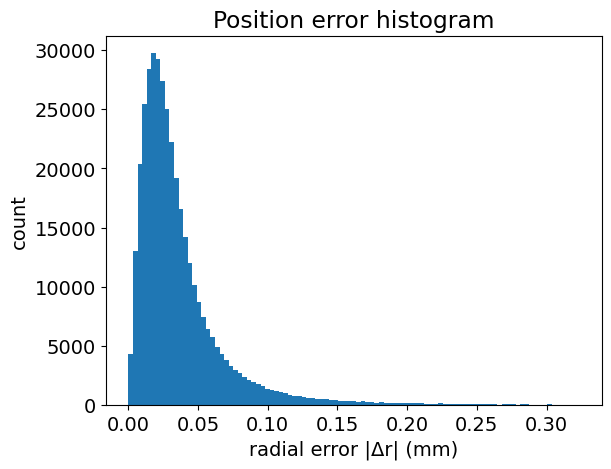

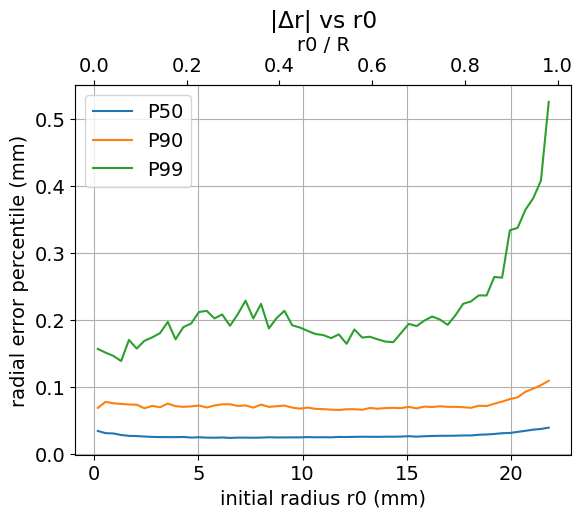

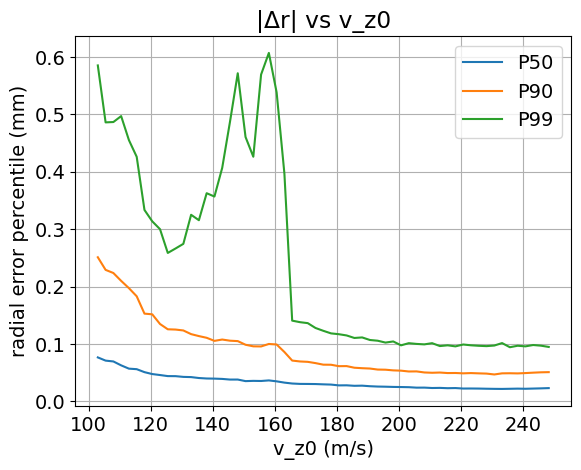

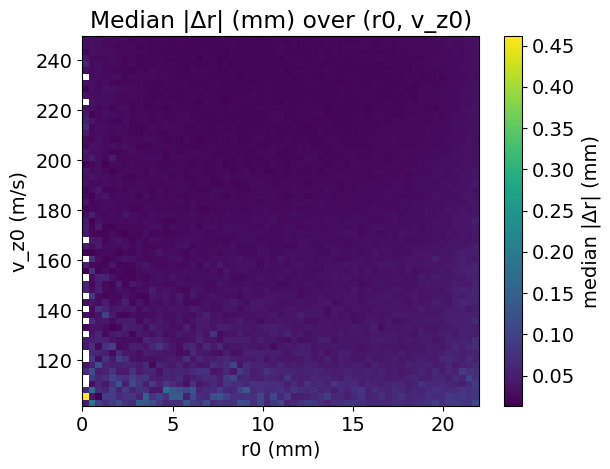

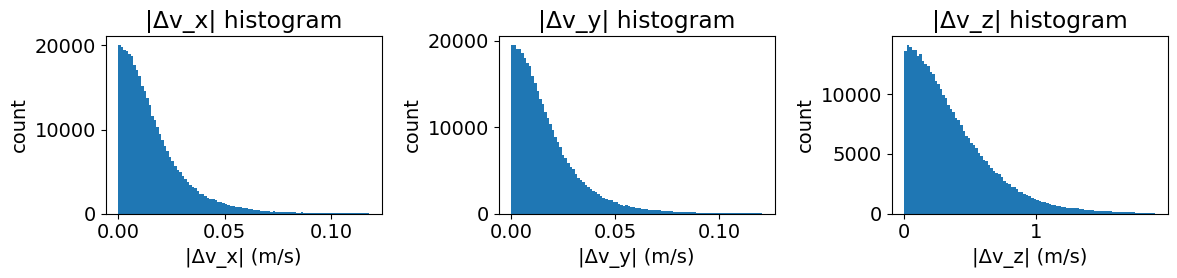

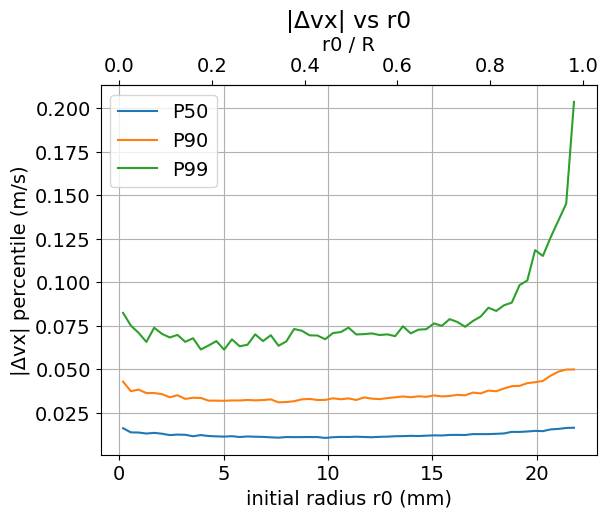

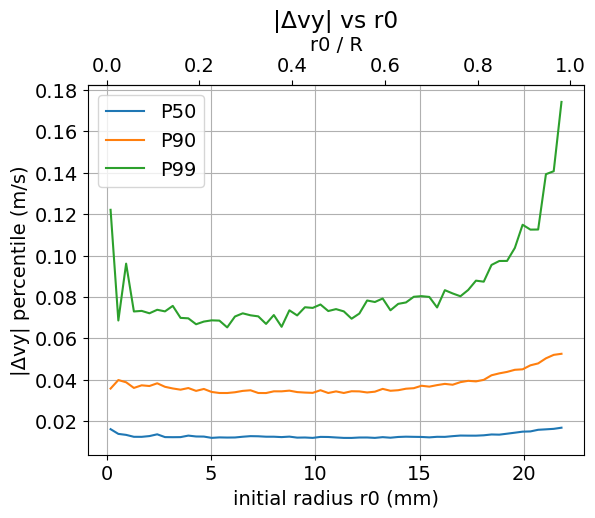

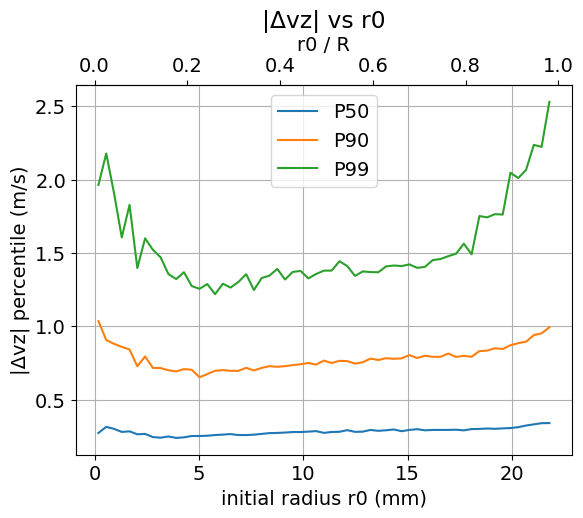

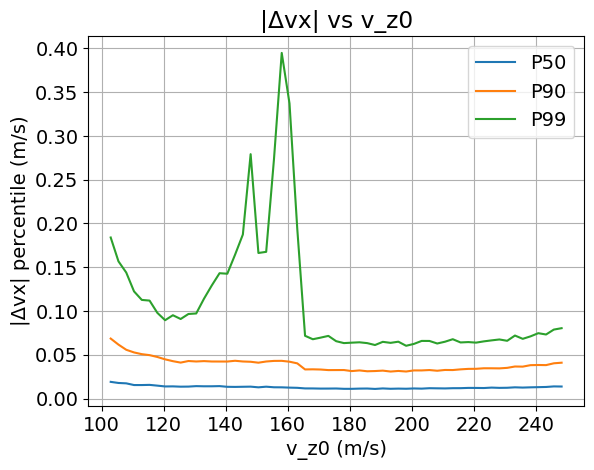

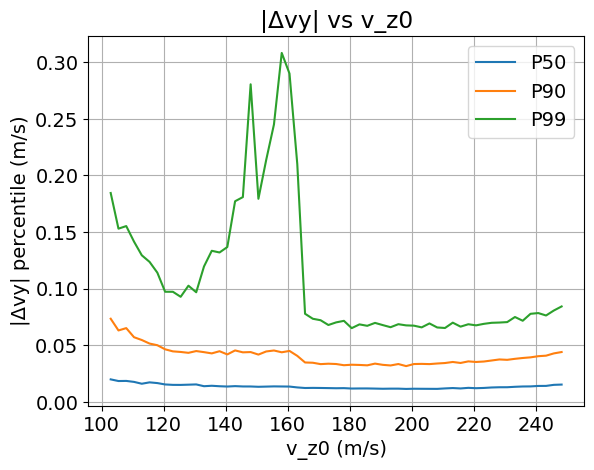

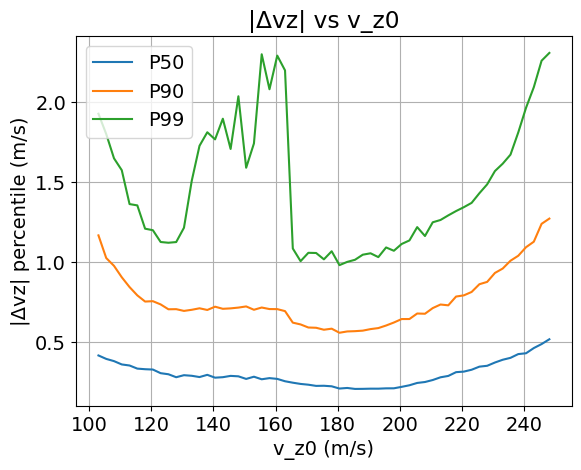

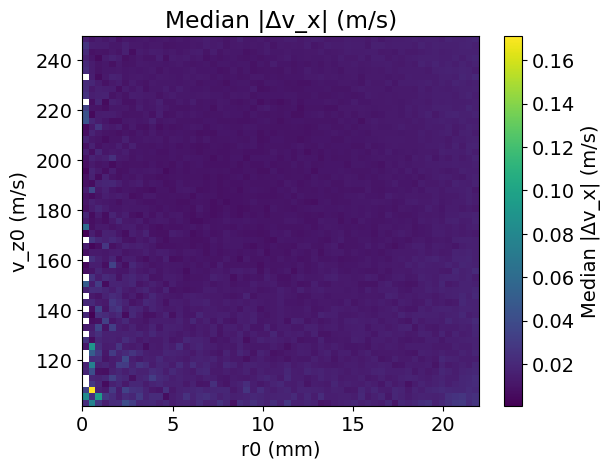

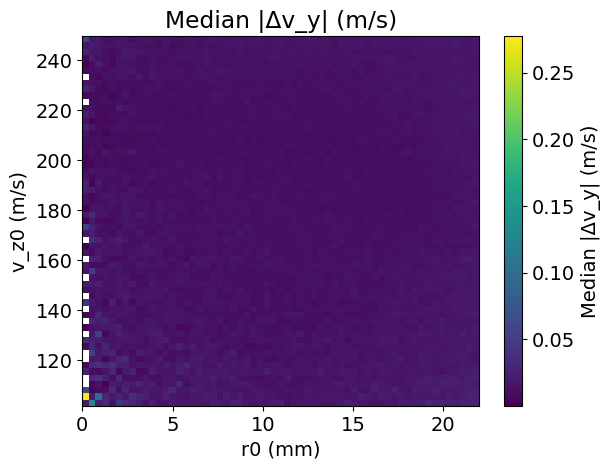

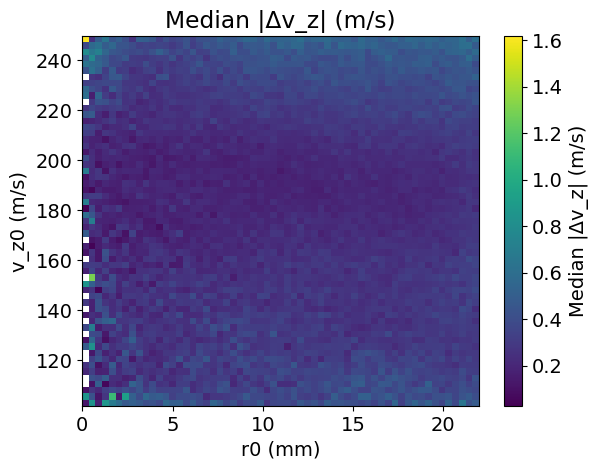

In [21]:
show_error_plots_full(emap, R=R)

In [22]:
n_eval = 20_000

x0 = rng.uniform(-0.8 * R, 0.8 * R, n_eval).astype(np.float32)
y0 = rng.uniform(-0.8 * R, 0.8 * R, n_eval).astype(np.float32)
vx = rng.uniform(-10.0, 10.0, n_eval).astype(np.float32)
vy = rng.uniform(-10.0, 10.0, n_eval).astype(np.float32)
vz = rng.uniform(100.0, 250.0, n_eval).astype(np.float32)
V_eval = np.full(n_eval, 20_000.0, dtype=np.float32)  # choose any voltage in-range


p, survive, x_out, y_out, vx_out, vy_out, vz_out = sg_xyv.predict(
    x0,
    y0,
    vx,
    vy,
    vz,
    V_eval,  # V_eval can be array or scalar like 25_000
)

In [23]:
%%timeit
p, survive, x_out, y_out, vx_out, vy_out, vz_out = sg_xyv.predict(
    x0,
    y0,
    vx,
    vy,
    vz,
    V_eval,  # V_eval can be array or scalar like 25_000
)

58.1 ms ± 1.99 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Text(0.5, 1.0, 'Survivor density')

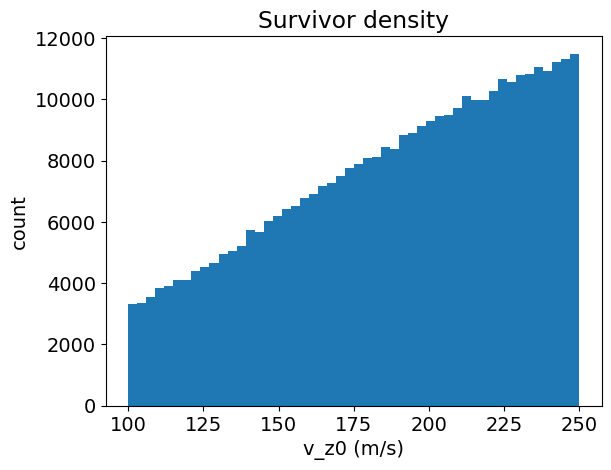

In [24]:
plt.hist(emap["vz0"], bins=50)
plt.xlabel("v_z0 (m/s)")
plt.ylabel("count")
plt.title("Survivor density")


Text(0, 0.5, '|Δr| (mm)')

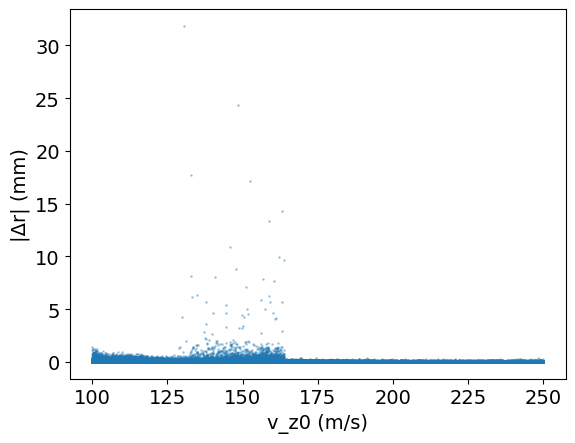

In [25]:
plt.scatter(emap["vz0"], emap["rerr"] * 1e3, s=1, alpha=0.3)
plt.xlabel("v_z0 (m/s)")
plt.ylabel("|Δr| (mm)")